In [1]:
# --- Experiment parameters

# Name of experiment. Used for MLflow experiment name, output files, etc.
experiment_name = "NT-M4-Torch-DataLoader"

# Paths
root = '/Users/ntin/Documents/DermaML_local/hawkeye-hands-2024-07-29'

image_folder = '/images_processed/'
features_folder = '/features-2025-02-24/'
csv_file = '/metadata.csv'
segmentation_folder = '/segmentation_npys/'

# ------ Algorithm parameters

# train/test split
split = 0.7
epochs = 10
learning_rate = 1e3

In [2]:
# --- Imports

# Internal library
from dermaml.data import read_local_into_dict, read_local_into_lists
from dermaml.model_setup import read_segmentation_npy, square_resize

# Standard library
import os
import random 
import math
from datetime import datetime
# External packages
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv
import pandas as pd
import torch
import torchvision


# Entropy
random.seed(42)
np.random.seed(42)

np.set_printoptions(precision=3, suppress=True)

Tutorial for dataloaders:  
[https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files]

In [17]:
from torchvision.io import decode_image
from torch.utils.data import Dataset
from torchvision import datasets

from PIL import Image

class HawkeyeHandsDataset(Dataset):
    def __init__(
            self, 
            metadata_file, 
            img_dir, 
            filename_jpeg, 
            label='age',
            metadata_filename_column = 'hand_image_file',
            transform=None, target_transform=None
            ):
        
        # load metadata
        self.metadata = pd.read_csv(metadata_file)
        self.metadata_filename_column = metadata_filename_column
        # filter metadata to only include images in dataset_filenames
        self.metadata = self.metadata[self.metadata[metadata_filename_column].isin(filename_jpeg)]
            
        # set labels
        self.classes = self.metadata[label]

        # load image files
        self.img_dir = img_dir
        self.filename_jpeg = filename_jpeg

        # set transformations
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.classes)

    def __getitem__(self, idx):
        fname = self.filename_jpeg[idx]

        # load in image
        img_path = os.path.join(self.img_dir, fname)
        # image = decode_image(img_path) # reads as tensor
        
        # read image as array
        image = Image.open(img_path)

        # get label for image
        label = self.metadata.loc[self.metadata[self.metadata_filename_column] == fname, 'age'].values[0]

        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)
        return image, label

In [22]:
annotations_file = root + '/metadata_processed.csv'
img_dir = root+image_folder

shuffled_im_files = os.listdir(root+image_folder)
random.shuffle(shuffled_im_files.copy())
# shuffled_im_files = [os.path.join(root+image_folder, f) for f in all_img_files]

splits = ['train', 'test']
image_count = len(shuffled_im_files)
train_size = math.floor(image_count * split)
train_files = shuffled_im_files[:train_size]
test_files = shuffled_im_files[train_size:]

print(len(train_files),)  # Expected: (403, 512, 512, 3) and (403, 1)
print(len(test_files))    # Expected: (N, 512, 512, 3) and (N, 1)

test_results = {}

transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((128, 128)),
    torchvision.transforms.ToTensor()
])

image_datasets = {x: HawkeyeHandsDataset(
                        metadata_file=annotations_file, 
                        img_dir=img_dir, 
                        filename_jpeg=data,
                        label='age',
                        metadata_filename_column='hand_image_file',
                        transform=transform,
                    )
                  for x, data in zip(['train', 'val'], [train_files, test_files])
                  }


439
189


In [23]:
image_datasets['train'].__getitem__(0)

(tensor([[[0.3569, 0.3490, 0.3451,  ..., 0.1373, 0.4275, 0.7529],
          [0.3608, 0.3529, 0.3451,  ..., 0.1412, 0.2588, 0.6824],
          [0.3608, 0.3529, 0.3451,  ..., 0.1529, 0.1804, 0.5686],
          ...,
          [0.3961, 0.3882, 0.3804,  ..., 0.2157, 0.2196, 0.2275],
          [0.4000, 0.3922, 0.3804,  ..., 0.2000, 0.2039, 0.2039],
          [0.4000, 0.3922, 0.3882,  ..., 0.1922, 0.1961, 0.1922]],
 
         [[0.6980, 0.6863, 0.6745,  ..., 0.3490, 0.5020, 0.7098],
          [0.6980, 0.6902, 0.6745,  ..., 0.3608, 0.4118, 0.6549],
          [0.6980, 0.6863, 0.6745,  ..., 0.3725, 0.3765, 0.5804],
          ...,
          [0.7725, 0.7647, 0.7529,  ..., 0.5216, 0.5176, 0.5137],
          [0.7765, 0.7686, 0.7569,  ..., 0.5059, 0.5059, 0.5020],
          [0.7765, 0.7647, 0.7529,  ..., 0.4941, 0.4980, 0.4902]],
 
         [[0.4392, 0.4314, 0.4196,  ..., 0.1765, 0.4196, 0.6941],
          [0.4392, 0.4353, 0.4235,  ..., 0.1843, 0.2745, 0.6314],
          [0.4392, 0.4314, 0.4196,  ...,

In [24]:
dataloaders = {x: torch.utils.data.DataLoader(
                        image_datasets[x], 
                        batch_size=4,
                        shuffle=True, 
                        num_workers=0,
                        )
              for x in ['train', 'val']
              }

In [25]:
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}

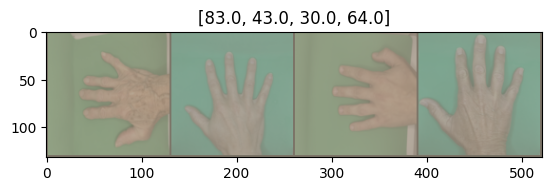

In [27]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[float(x) for x in classes])